In [3]:
import os
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
data_path = "data"
metadata_path = "sample_metadata.csv"

files = [f for f in os.listdir(data_path) if f.endswith(".tsv")]

print("Number of count files:", len(files))
print(files[:5])

Number of count files: 100
['6d9a6fb6-92be-4e51-a183-dbcc343fbcdd.rna_seq.augmented_star_gene_counts.tsv', '2be4a1d7-20fd-4399-8fe6-e611fbc33e69.rna_seq.augmented_star_gene_counts.tsv', '0d64986b-37a6-4f25-97c9-4fc5346cd057.rna_seq.augmented_star_gene_counts.tsv', '573ed713-ce22-445e-a77a-ba0a2a79644f.rna_seq.augmented_star_gene_counts.tsv', 'bd6344b2-bc0c-4787-a1ad-145522dc8df9.rna_seq.augmented_star_gene_counts.tsv']


In [5]:
dfs = []

for file in files:
    file_path = os.path.join(data_path, file)

    df = pd.read_csv(file_path, sep="\t", comment="#")
    df = df[["gene_name", "unstranded"]]
    df = df.dropna(subset=["gene_name"])

    df.columns = ["gene", file]
    df = df.set_index("gene")

    dfs.append(df)

combined = pd.concat(dfs, axis=1)

print(combined.shape)
combined.head()

(60660, 100)


,6d9a6fb6-92be-4e51-a183-dbcc343fbcdd.rna_seq.augmented_star_gene_counts.tsv,2be4a1d7-20fd-4399-8fe6-e611fbc33e69.rna_seq.augmented_star_gene_counts.tsv,0d64986b-37a6-4f25-97c9-4fc5346cd057.rna_seq.augmented_star_gene_counts.tsv,573ed713-ce22-445e-a77a-ba0a2a79644f.rna_seq.augmented_star_gene_counts.tsv,bd6344b2-bc0c-4787-a1ad-145522dc8df9.rna_seq.augmented_star_gene_counts.tsv,97fd1e0f-b859-495a-b598-8ca8c737788b.rna_seq.augmented_star_gene_counts.tsv,5fc33ea3-5008-4b88-b672-8358213db14c.rna_seq.augmented_star_gene_counts.tsv,68893143-096d-4ef8-8d69-58cbad1de75d.rna_seq.augmented_star_gene_counts.tsv,e2a03b03-5cea-4566-9052-65189892c042.rna_seq.augmented_star_gene_counts.tsv,00c86d63-088e-4f59-af89-61f37536bb9a.rna_seq.augmented_star_gene_counts.tsv,...,d246e892-e276-4c69-b28c-c6f64ab5a8ec.rna_seq.augmented_star_gene_counts.tsv,fec66e5a-6526-4f95-ae0e-ad819ad16a3c.rna_seq.augmented_star_gene_counts.tsv,6819c7ed-6f9f-44d4-9cf1-da669c5e60ff.rna_seq.augmented_star_gene_counts.tsv,89b086d1-2d13-4939-a102-f5c88c44d80c.rna_seq.augmented_star_gene_counts.tsv,e3e899e6-67d1-4087-8b10-327a4aacadea.rna_seq.augmented_star_gene_counts.tsv,74e4cad1-e75a-4ab4-a79e-d3ca48d77b60.rna_seq.augmented_star_gene_counts.tsv,5e1b3528-dc3b-43ef-93ab-7285763fefe7.rna_seq.augmented_star_gene_counts.tsv,710a199c-93a1-463b-8f09-8cba6f15eb77.rna_seq.augmented_star_gene_counts.tsv,6c8e3af5-9adf-457d-a108-58ad5b57c6f4.rna_seq.augmented_star_gene_counts.tsv,9fe8a9eb-ee3c-4c10-8f5f-01e120c43b6f.rna_seq.augmented_star_gene_counts.tsv
gene,,,,,,,,,,,,,,,,,,,,,
TSPAN6,2517,2457,2789,1506,738,1413,391,3648,872,1212,...,3309,640,1198,2354,4933,3825,905,857,2174,347
TNMD,36,2,1,94,4,31,6,4,13,19,...,11,34,18,5,2,12,31,13,21,4
DPM1,1340,3164,1266,1054,934,737,867,1448,540,829,...,1256,1403,953,1280,2426,1184,843,666,1100,518
SCYL3,796,1359,950,1183,1053,1151,479,4223,769,1009,...,1563,1221,1283,907,974,1415,1216,488,1127,619
C1orf112,583,1233,843,293,304,348,175,1728,206,348,...,489,420,387,430,207,433,1353,150,410,159


In [6]:
combined_t = combined.T.reset_index().rename(columns={"index": "sample_id"})

print(combined_t.shape)
combined_t.head()

(100, 60661)


gene,sample_id,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AL451106.1,AC092910.4,AC073611.1,AC136977.1,AC078856.1,AC008763.4,AL592295.6,AC006486.3,AL391628.1,AP006621.6
0,6d9a6fb6-92be-4e51-a183-dbcc343fbcdd.rna_seq.a...,2517,36,1340,796,583,240,4472,1121,1998,...,0,10,22,0,28,2,288,0,5,6
1,2be4a1d7-20fd-4399-8fe6-e611fbc33e69.rna_seq.a...,2457,2,3164,1359,1233,1,333,4448,5573,...,0,15,130,0,29,0,710,0,25,19
2,0d64986b-37a6-4f25-97c9-4fc5346cd057.rna_seq.a...,2789,1,1266,950,843,790,1479,1683,1679,...,0,15,79,0,29,0,229,0,22,9
3,573ed713-ce22-445e-a77a-ba0a2a79644f.rna_seq.a...,1506,94,1054,1183,293,345,22481,906,2436,...,0,12,31,0,36,0,387,0,12,9
4,bd6344b2-bc0c-4787-a1ad-145522dc8df9.rna_seq.a...,738,4,934,1053,304,2007,13490,1407,1507,...,0,10,23,0,50,1,207,0,17,6


In [7]:
X = combined_t.drop(columns=["sample_id"])
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

keep_genes = (X > 10).sum(axis=0) >= 3
X = X.loc[:, keep_genes]

print(X.shape)

(100, 43146)


In [8]:
X_cpm = X.div(X.sum(axis=1), axis=0) * 1_000_000
X_log = np.log1p(X_cpm)

X_log.head()

gene,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AC020765.6,AL139280.3,AC010980.1,AC004233.4,AC092910.4,AC073611.1,AC078856.1,AL592295.6,AL391628.1,AP006621.6
0,4.554652,0.852503,3.933450,3.425914,3.126313,2.299588,5.124811,3.758819,4.326459,3.766630,...,0.289963,1.000361,0.579352,0.000000,0.317547,0.600076,0.716135,2.465052,0.171325,0.202330
1,3.684182,0.031105,3.931449,3.112080,3.019320,0.015673,1.834229,4.266388,4.489031,3.936703,...,0.076019,0.000000,0.000000,0.031105,0.212649,1.116312,0.377138,2.502719,0.332836,0.262470
2,4.058427,0.020190,3.289176,3.014347,2.901062,2.839808,3.439296,3.564611,3.562299,3.665572,...,0.151144,0.000000,0.297675,0.020190,0.266918,0.959828,0.464659,1.735292,0.370668,0.168527
3,3.543109,1.129983,3.198572,3.309572,2.019166,2.162324,6.218966,3.053910,4.012906,3.087010,...,0.022049,0.000000,0.043622,0.022049,0.237065,0.525381,0.589214,2.264639,0.237065,0.182857
4,2.970476,0.095562,3.195190,3.310472,2.154212,3.937969,5.826549,3.591063,3.657893,3.375989,...,0.048922,0.000000,0.161681,0.024760,0.223698,0.455268,0.812471,1.822832,0.354999,0.140124


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["sample_id"] = combined_t["sample_id"].astype(str).str.strip()
pca_df["file_uuid"] = pca_df["sample_id"].str.split(".").str[0].astype(str).str.strip()

print(pca_df.head())
print("PC1 variance:", pca.explained_variance_ratio_[0])
print("PC2 variance:", pca.explained_variance_ratio_[1])

          PC1         PC2                                          sample_id  \
0  115.331161  214.420384  6d9a6fb6-92be-4e51-a183-dbcc343fbcdd.rna_seq.a...   
1 -113.886128   42.282578  2be4a1d7-20fd-4399-8fe6-e611fbc33e69.rna_seq.a...   
2  -47.351686   28.550398  0d64986b-37a6-4f25-97c9-4fc5346cd057.rna_seq.a...   
3   -7.580994  -26.629854  573ed713-ce22-445e-a77a-ba0a2a79644f.rna_seq.a...   
4   67.681995  -69.363526  bd6344b2-bc0c-4787-a1ad-145522dc8df9.rna_seq.a...   

                              file_uuid  
0  6d9a6fb6-92be-4e51-a183-dbcc343fbcdd  
1  2be4a1d7-20fd-4399-8fe6-e611fbc33e69  
2  0d64986b-37a6-4f25-97c9-4fc5346cd057  
3  573ed713-ce22-445e-a77a-ba0a2a79644f  
4  bd6344b2-bc0c-4787-a1ad-145522dc8df9  
PC1 variance: 0.15705527426775528
PC2 variance: 0.08187180037394859


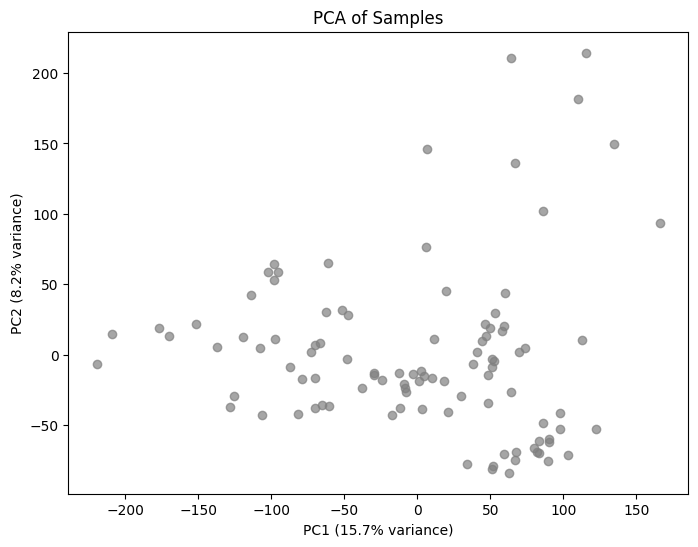

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], color="gray", alpha=0.7)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of Samples")
plt.show()

In [11]:
meta = pd.read_csv(metadata_path, sep="\t")

print(meta.columns.tolist())
print(meta.head())


['File ID', 'File Name', 'Data Category', 'Data Type', 'Project ID', 'Case ID', 'Sample ID', 'Tissue Type', 'Tumor Descriptor', 'Specimen Type', 'Preservation Method']
                                File ID  \
0  8673b4fa-26f8-441b-93ab-5aea6b8b377a   
1  70f17418-6373-4928-ac14-64c61fa0650a   
2  6f304ec1-d4ad-4cfe-80a2-2036b3871ae6   
3  e0037b7b-2122-4859-ad32-398852a3d4a5   
4  3116035f-39cb-42d9-8675-c3e58527705c   

                                           File Name            Data Category  \
0  2aab05fb-874d-487f-91c8-08b590753414.rna_seq.a...  Transcriptome Profiling   
1  dcd92f62-bed1-4718-a918-6eda2855366a.rna_seq.a...  Transcriptome Profiling   
2  87ebb940-db9d-45f4-abe6-a2b6bb976034.rna_seq.a...  Transcriptome Profiling   
3  89b086d1-2d13-4939-a102-f5c88c44d80c.rna_seq.a...  Transcriptome Profiling   
4  63af2405-350e-4304-af91-dd95e269b38d.rna_seq.a...  Transcriptome Profiling   

                        Data Type Project ID            Case ID  \
0  Gene Expression 

In [12]:
meta = pd.read_csv("sample_metadata.csv", sep="\t")

meta["File Name"] = meta["File Name"].astype(str).str.strip()
pca_df["sample_id"] = pca_df["sample_id"].astype(str).str.strip()

pca_merged = pca_df.merge(
    meta,
    left_on="sample_id",
    right_on="File Name",
    how="left"
)

print(pca_merged[["sample_id", "File Name", "Tissue Type"]].head())
print(pca_merged["Tissue Type"].value_counts(dropna=False))


                                           sample_id  \
0  6d9a6fb6-92be-4e51-a183-dbcc343fbcdd.rna_seq.a...   
1  2be4a1d7-20fd-4399-8fe6-e611fbc33e69.rna_seq.a...   
2  0d64986b-37a6-4f25-97c9-4fc5346cd057.rna_seq.a...   
3  573ed713-ce22-445e-a77a-ba0a2a79644f.rna_seq.a...   
4  bd6344b2-bc0c-4787-a1ad-145522dc8df9.rna_seq.a...   

                                           File Name Tissue Type  
0  6d9a6fb6-92be-4e51-a183-dbcc343fbcdd.rna_seq.a...       Tumor  
1  2be4a1d7-20fd-4399-8fe6-e611fbc33e69.rna_seq.a...       Tumor  
2  0d64986b-37a6-4f25-97c9-4fc5346cd057.rna_seq.a...       Tumor  
3  573ed713-ce22-445e-a77a-ba0a2a79644f.rna_seq.a...      Normal  
4  bd6344b2-bc0c-4787-a1ad-145522dc8df9.rna_seq.a...      Normal  
Tissue Type
Normal          50
Tumor           46
Tumor, Tumor     4
Name: count, dtype: int64


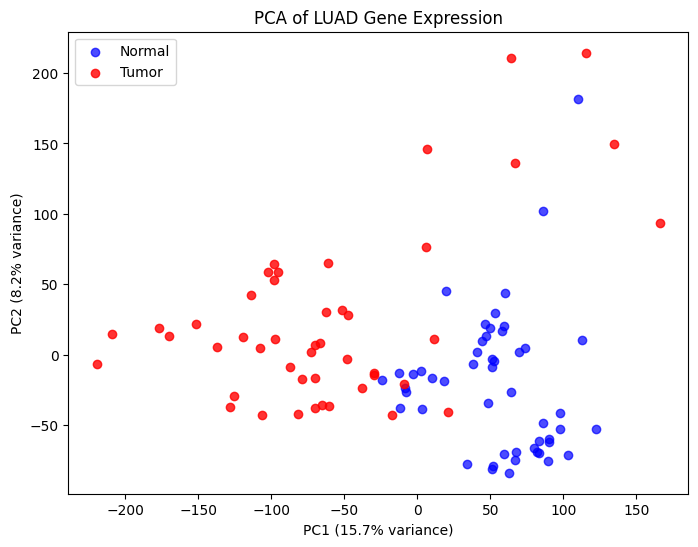

In [14]:
tumor = pca_merged[pca_merged["Tissue Type"] == "Tumor"]
normal = pca_merged[pca_merged["Tissue Type"] == "Normal"]

plt.figure(figsize=(8, 6))
plt.scatter(normal["PC1"], normal["PC2"], color="blue", alpha=0.7, label="Normal")
plt.scatter(tumor["PC1"], tumor["PC2"], color="red", alpha=0.8, label="Tumor")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of LUAD Gene Expression")
plt.legend()

plt.savefig("pca_plot.png", dpi=300, bbox_inches="tight")

plt.show()

In [24]:
pca_merged.to_csv("pca_with_metadata.csv", index=False)